# Assignment 3 — IMDB Sentiment & Regularisation

**DATAX504** · Due end of Week 6

Build on **Chapter 5** (regularisation / early stopping) and **Chapter 7** (Keras `compile` / `fit`, callbacks, saving). A compact Sequential stack is fine; you may use the **Functional API** if you prefer (same depth of learning either way).

## Tasks
1. Load IMDB, pad sequences, create a train / validation split
2. Train a **baseline** sentiment model and record best validation accuracy
3. Produce a **diagram** of your model architecture (see §2b)
4. Apply **two** of: L2, dropout, early stopping — report best val accuracy and name the techniques
5. Learning-rate schedule experiment (`ReduceLROnPlateau` or `LearningRateScheduler`)
6. Save the model you consider best with `model.save(...)` and check that it reloads
7. ~200-word reflection on what you learned

## Moodle fields
`a3_repo`, `a3_baseline_val`, `a3_best_val`, `a3_techniques`, `a3_model_file`

## AI disclosure (required)
Fill the table in the next cell before you submit.

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | OpenCode + Claude Sonnet 5 Anthropic |
| Used for | Assistance on python syntax and debugging, research on ReduceLROnPlateau and Embedding|
| Verified how | Running the scripts and checking with plots and output |
| Not used for | Final write ups, reading up on IMDB and various ideas on how to model it via google (it was annoying me that I couldn't improve the accuracy very much)|

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, regularizers, callbacks
import random
import tensorflow as tf 

def set_seed(seed=9307035):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Optional for plot_model (Ch 7). If import fails, use model.summary() + a drawn sketch (see §2b).
try:
    from keras.utils import plot_model
except ImportError:
    plot_model = None

## 1. Load & prepare IMDB

Hints (fill in the blanks):
- `keras.datasets.imdb.load_data(num_words=...)`
- pad both train and test with `keras.utils.pad_sequences(..., maxlen=...)`
- hold out the **first 10_000** padded training examples as validation (Ch 4 / 5 style split)
- keep the rest of the training set for fitting

In [2]:
max_features = 10000 #most frequent words are in lower indices
max_len = 500 #max review length

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features) #no validation set
print("original train:", getattr(x_train, "shape", None), getattr(y_train, "shape", None))
print("original test: ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))

# TODO: pad sequences so every review has length max_len
x_train = keras.utils.pad_sequences(x_train, maxlen=max_len)  # pad_sequences(...) #will prepad with 0 to 500
x_test = keras.utils.pad_sequences(x_test, maxlen=max_len)

# TODO: validation split — first 10_000 samples for val, remainder for train
x_val = x_train[:10000] #0-9999 
y_val = y_train[:10000] #0-9999 
x_train = x_train[10000:] #remainder 10000-24999 
y_train = y_train[10000:] #remainder 10000-24999 

print("train:", getattr(x_train, "shape", None), getattr(y_train, "shape", None)) #remainder 15,000
print("val:  ", getattr(x_val, "shape", None), getattr(y_val, "shape", None))  #first 10,000
print("test: ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))  #original 25,000

#IMDB
#0 → negative review
#1 → positive review
print(y_val.mean(), y_train.mean()) #check validation split

original train: (25000,) (25000,)
original test:  (25000,) (25000,)
train: (15000, 500) (15000,)
val:   (10000, 500) (10000,)
test:  (25000, 500) (25000,)
0.5053 0.49646666666666667


## 2. Baseline model

Suggested architecture (you may change widths if you document why):
1. `Embedding(max_features, 32, input_length=max_len)` — turns token ids into vectors
2. `GlobalAveragePooling1D()` — mean over the time axis
3. `Dense(32, activation="relu")`
4. `Dense(1, activation="sigmoid")` — binary sentiment

Then:
- `compile` with a suitable optimizer, **binary cross-entropy** loss, and accuracy metric
- `fit` with `validation_data=(x_val, y_val)` for ~10 epochs (batch size is your choice; 512 is common for this data)
- record the **best** validation accuracy over epochs for Moodle `a3_baseline_val`

In [3]:
def build_baseline():
    # TODO: build Sequential (or Functional) model, compile, return it
    inputs = keras.Input(shape=(max_len,),name="imdb_inputs") #shape is the number of features/or one samples dimensions #max review length
    features = layers.Embedding(max_features, 32,name ="Embedding")(inputs) #length
    features = layers.GlobalAveragePooling1D(name="GlobalAvPooling")(features)
    features = layers.Dense(32,activation="relu", name="dense_relu")(features)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(features)
    model = keras.Model(inputs=inputs, outputs=outputs, name="baseline_model")
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]) #binary_crossentropy matches to sigmoid
    return model

set_seed(9307035)
baseline = build_baseline() #baseline model

# fit and keep the History object
hist_baseline = baseline.fit(
     x_train, y_train,
     epochs=20,
     batch_size=512,
     validation_data=(x_val, y_val),
     #callbacks=[checkpoint_cb],
     verbose=1,  #show progress bar
 )

# best validation accuracy across epochs
baseline_val_acc = max(hist_baseline.history["val_accuracy"])
#baseline_val_acc = None
print(f"Baseline best val accuracy (Moodle a3_baseline_val): {baseline_val_acc}")

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.5232 - loss: 0.6919 - val_accuracy: 0.5306 - val_loss: 0.6907
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6069 - loss: 0.6844 - val_accuracy: 0.7042 - val_loss: 0.6770
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6792 - loss: 0.6642 - val_accuracy: 0.6954 - val_loss: 0.6502
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.6950 - loss: 0.6290 - val_accuracy: 0.7375 - val_loss: 0.6095
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.7651 - loss: 0.5784 - val_accuracy: 0.7621 - val_loss: 0.5603
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.7870 - loss: 0.5247 - val_accuracy: 0.8062 - val_loss: 0.5038
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8146 - loss: 0.4728 - val_accuracy: 0.8148 - val_loss: 0.4660
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8355 - loss: 0.4298 - val_accuracy: 0.8028 - v

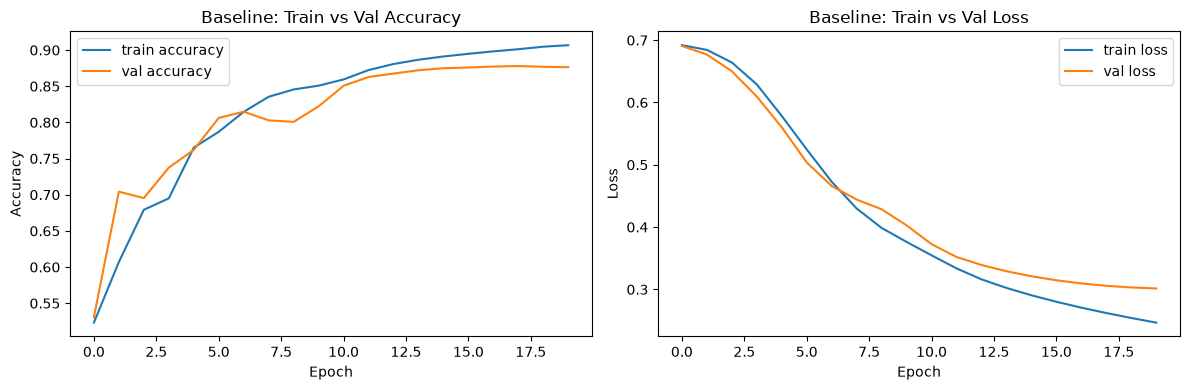

In [4]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist_baseline.history["accuracy"], label="train accuracy")
plt.plot(hist_baseline.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline: Train vs Val Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_baseline.history["loss"], label="train loss")
plt.plot(hist_baseline.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline: Train vs Val Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 2b. Diagram of your architecture (required)

You *can* do this with the tools from **Chapter 7 / Week 5**:

```python
keras.utils.plot_model(
    baseline,                      # or your regularised model
    to_file="imdb_model.png",      # commit this image to your repo
    show_shapes=True,
    show_layer_names=True,
)
```

Also print `model.summary()` so layer shapes appear in the notebook.

**If `plot_model` fails** (missing Graphviz / pydot on your machine):
1. Keep a full `model.summary()` output in the notebook, and
2. Add a short markdown diagram or hand-drawn photo of the stack (Embedding → … → sigmoid).

Either way, a reader should see the full forward path without reading all of your code.

In [5]:
# TODO: print architecture summary
baseline.summary()

# TODO: save a DAG figure when Graphviz/pydot are available
DIAGRAM_FILE = "imdb_model.png"
if plot_model is not None:
    try:
        plot_model(
            baseline,  # swap for reg_model later if you prefer that diagram
            to_file=DIAGRAM_FILE,
            show_shapes=True,
            show_layer_names=True,
        )
        print(f"Wrote {DIAGRAM_FILE} — commit it to your GitHub repo")
        # Optional: display in notebook
        from IPython.display import HTML, display
        display(HTML(f'<div style="text-align: center;"><img src="{DIAGRAM_FILE}" width="400"></div>'))
    except Exception as e:
        print("plot_model failed — use summary + hand diagram:", e)
else:
    print("plot_model unavailable — use model.summary() and a markdown/hand diagram")

Model: "baseline_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ imdb_inputs (InputLayer)             │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Embedding (Embedding)                │ (None, 500, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ GlobalAvPooling                      │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_relu (Dense)                   │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 963,269 (3.67 MB)

 Trainable params: 321,089 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 642,180 (2.45 MB)

Wrote imdb_model.png — commit it to your GitHub repo


## 3. Regularised model

Choose **exactly two** (or more if curious, but Moodle asks for two) of:

| Technique | Typical hook |
|-----------|----------------|
| L2 | `kernel_regularizer=regularizers.l2(...)` on a Dense layer |
| Dropout | `layers.Dropout(rate)` after a Dense / before the output |
| Early stopping | `callbacks.EarlyStopping(monitor="val_loss", patience=..., restore_best_weights=True)` |

Hints:
- Set boolean flags below so you can print which techniques you used
- `compile` again after building the stack
- Pass a **list of callbacks** into `fit` (empty list if you did not pick early stopping)
- Train long enough that early stopping might fire (e.g. more epochs than the baseline)
- Best val accuracy → Moodle `a3_best_val`; names → `a3_techniques`

In [7]:
def build_reg_model(dropout_rate=0.2, dense_units=32, embed_dim=32,
                     use_l2=False, l2_strength=1e-4):
    l2_reg = regularizers.l2(l2_strength) if use_l2 else None
    inputs = keras.Input(shape=(max_len,), name="imdb_inputs")
    features = layers.Embedding(max_features, embed_dim, name="embedding")(inputs)
    features = layers.GlobalAveragePooling1D(name="global_avg_pooling")(features)
    features = layers.Dense(dense_units, activation="relu",
                             kernel_regularizer=l2_reg, name="dense_relu")(features)
    features = layers.Dropout(dropout_rate, name="dropout")(features)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(features)
    model = keras.Model(inputs=inputs, outputs=outputs, name="reg_model")
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [8]:
USE_L2 = False          # set True if using L2
USE_DROPOUT = True     # set True if using dropout
USE_EARLY_STOP = True  # set True if using EarlyStopping

set_seed(9307035)
reg_model = build_reg_model(dropout_rate=0.2 if USE_DROPOUT else 0.0,
                             dense_units=32,
                             use_l2=USE_L2)
reg_model.summary()

reg_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]) #binary_crossentropy matches to sigmoid

cb = []
if USE_EARLY_STOP:
     cb.append(callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2, #go two epoch forward of a plateua
        restore_best_weights=True ))#roll back to best weights

#  fit → hist_reg
hist_reg = reg_model.fit(
     x_train, y_train,
     callbacks=cb,
     epochs=25, #bumped up from 10 as early stopping did not fire until later
     batch_size=512,
     validation_data=(x_val, y_val),
     verbose=1,  # progress bar
 )

best_val_acc = max(hist_reg.history["val_accuracy"])
techniques = []
if USE_L2:
    techniques.append("L2")
if USE_DROPOUT:
    techniques.append("dropout")
if USE_EARLY_STOP:
    techniques.append("early stopping")

print(f"Techniques (Moodle a3_techniques): {', '.join(techniques)}")
print(f"Best val accuracy (Moodle a3_best_val): {best_val_acc}")
assert len(techniques) >= 2, "Enable (at least) two techniques for full credit"

Model: "reg_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ imdb_inputs (InputLayer)             │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 500, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_avg_pooling                   │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_relu (Dense)                   │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 321,089 (1.22 MB)

 Trainable params: 321,089 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.5289 - loss: 0.6904 - val_accuracy: 0.6150 - val_loss: 0.6852
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.6115 - loss: 0.6772 - val_accuracy: 0.6679 - val_loss: 0.6654
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.6671 - loss: 0.6498 - val_accuracy: 0.6408 - val_loss: 0.6363
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7311 - loss: 0.6043 - val_accuracy: 0.7403 - val_loss: 0.5832
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.7663 - loss: 0.5498 - val_accuracy: 0.8036 - val_loss: 0.5220
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.7968 - loss: 0.4929 - val_accuracy: 0.7323 - val_loss: 0.5079
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8141 - loss: 0.4504 - val_accuracy: 0.7664 - val_loss: 0.4693
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.8257 - loss: 0.4173 - val_accuracy: 0.8380 - v

**Testing Different Hyperparameters:**

Testing different values for the Embedding Dimension

In [9]:
for embed_dim in [8, 16, 32, 64, 128]:
    keras.backend.clear_session()
    set_seed(9307035)
    m = build_reg_model(dropout_rate=0.2, dense_units=32, embed_dim=embed_dim)
    cb = [callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
    h = m.fit(x_train, y_train, epochs=60, batch_size=512,
              validation_data=(x_val, y_val), callbacks=cb, verbose=0)
    print(f"embed_dim={embed_dim}: {max(h.history['val_accuracy']):.4f} "
          f"(stopped at epoch {len(h.history['val_loss'])})", flush=True)


embed_dim=8: 0.8909 (stopped at epoch 34)
embed_dim=16: 0.8833 (stopped at epoch 26)
embed_dim=32: 0.8882 (stopped at epoch 25)
embed_dim=64: 0.8774 (stopped at epoch 19)
embed_dim=128: 0.7624 (stopped at epoch 9)


**Testing Different Hyperparameters:**

Testing different drop out rates and dense layer widths

In [10]:
import pandas as pd
dropout_rates = [0.1, 0.2, 0.3, 0.5]
dense_widths = [32, 64, 128]

results = []

for width in dense_widths:
    for rate in dropout_rates:
        print(f"width={width}, dropout={rate}...", flush=True)
        keras.backend.clear_session()
        set_seed(9307035)
        model = build_reg_model(rate, dense_units=width)
        cb = [callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
        hist = model.fit(
            x_train, y_train,
            epochs=60,
            batch_size=512,
            validation_data=(x_val, y_val),
            callbacks=cb,
            verbose=0,
        )
        best_acc = max(hist.history["val_accuracy"])
        results.append({"dense_units": width, "dropout": rate, "val_acc": best_acc})
        print(f"  -> {best_acc:.4f}", flush=True)

df_matched = pd.DataFrame(results)
df_matched

width=32, dropout=0.1...
  -> 0.8826
width=32, dropout=0.2...
  -> 0.8882
width=32, dropout=0.3...
  -> 0.8901
width=32, dropout=0.5...
  -> 0.8905
width=64, dropout=0.1...
  -> 0.8741
width=64, dropout=0.2...
  -> 0.8740
width=64, dropout=0.3...
  -> 0.8761
width=64, dropout=0.5...
  -> 0.8808
width=128, dropout=0.1...
  -> 0.8768
width=128, dropout=0.2...
  -> 0.8020
width=128, dropout=0.3...
  -> 0.8318
width=128, dropout=0.5...
  -> 0.8868


,dense_units,dropout,val_acc
0,32,0.1,0.8826
1,32,0.2,0.8882
2,32,0.3,0.8901
3,32,0.5,0.8905
4,64,0.1,0.8741
5,64,0.2,0.8740
6,64,0.3,0.8761
7,64,0.5,0.8808
8,128,0.1,0.8768
9,128,0.2,0.8020


In [11]:
set_seed(9307035)
l2_only_model = build_reg_model(dropout_rate=0.0, dense_units=32, use_l2=True, l2_strength=1e-4)

cb = [callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]

hist_l2 = l2_only_model.fit(
    x_train, y_train,
    callbacks=cb,
    epochs=30,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1,
)

l2_val_acc = max(hist_l2.history["val_accuracy"])
print(f"L2-only best val accuracy: {l2_val_acc}")

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.5217 - loss: 0.6945 - val_accuracy: 0.5411 - val_loss: 0.6923
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.6031 - loss: 0.6868 - val_accuracy: 0.6779 - val_loss: 0.6803
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.6718 - loss: 0.6693 - val_accuracy: 0.7222 - val_loss: 0.6564
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.6933 - loss: 0.6373 - val_accuracy: 0.6802 - val_loss: 0.6221
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.7564 - loss: 0.5892 - val_accuracy: 0.7585 - val_loss: 0.5708
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7849 - loss: 0.5360 - val_accuracy: 0.8059 - val_loss: 0.5159
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.8143 - loss: 0.4840 - val_accuracy: 0.8225 - val_loss: 0.4721
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8338 - loss: 0.4410 - val_accuracy: 0.7930 - v

**Testing with a CNN layer:**

Reason for test - GlobalAveragePooling1d - averages Embedding output into single vector so word order is lost.  Conv1D slides and can consider local patterns like word negation.
Based on reading up on potential different tests and some ideas on different layering strategies.

In [12]:
def build_conv_model(filters=128, kernel_size=5, dropout_rate=0.5, dense_units=64):
    inputs = keras.Input(shape=(max_len,), name="imdb_inputs")
    x = layers.Embedding(max_features, 64, name="embedding")(inputs)
    x = layers.Dropout(0.2, name="embed_dropout")(x)
    x = layers.Conv1D(filters, kernel_size, activation="relu", name="conv1d")(x)
    x = layers.GlobalMaxPooling1D(name="global_max_pooling")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    x = layers.Dense(dense_units, activation="relu", name="dense_relu")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="conv_model")
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

set_seed(9307035)
conv_model = build_conv_model()
conv_model.summary()

cb = [callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

hist_conv = conv_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=cb,
    verbose=1,
)

conv_val_acc = max(hist_conv.history["val_accuracy"])
print(f"Conv1D best val accuracy: {conv_val_acc}")

Model: "conv_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ imdb_inputs (InputLayer)             │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 500, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embed_dropout (Dropout)              │ (None, 500, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 496, 128)            │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling                   │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_relu (Dense)                   │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 689,409 (2.63 MB)

 Trainable params: 689,409 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5212 - loss: 0.6913 - val_accuracy: 0.5098 - val_loss: 0.6820
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6363 - loss: 0.6407 - val_accuracy: 0.6832 - val_loss: 0.5757
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7426 - loss: 0.5235 - val_accuracy: 0.7979 - val_loss: 0.4373
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.8228 - loss: 0.4043 - val_accuracy: 0.8446 - val_loss: 0.3541
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 417s 13s/step - accuracy: 0.8724 - loss: 0.3097 - val_accuracy: 0.8662 - val_loss: 0.3136
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 354s 12s/step - accuracy: 0.9077 - loss: 0.2410 - val_accuracy: 0.8738 - val_loss: 0.3056
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 342s 10s/step - accuracy: 0.9353 - loss: 0.1734 - val_accuracy: 0.8738 - val_loss: 0.3191
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 382s 13s/step - accuracy: 0.9539 - loss: 0.1298 - val_accuracy: 0.8737 - 

## 4. Learning-rate schedule

Week 5 / Ch 7 callback: try **`ReduceLROnPlateau`** (shrink LR when `val_loss` stalls)
or a custom **`LearningRateScheduler`**.

Hints:
- Start from the baseline or your regularised architecture (`build_baseline()` is fine)
- Put the schedule callback in the `callbacks=[...]` list for `fit`
- After training, plot the learning-rate history if present (`hist.history.get("lr", [])` for ReduceLROnPlateau)
- Short markdown below: which schedule, why those hyperparameters, what you observed

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.5232 - loss: 0.6919 - val_accuracy: 0.5306 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.6069 - loss: 0.6844 - val_accuracy: 0.7042 - val_loss: 0.6770 - learning_rate: 0.0010
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6792 - loss: 0.6642 - val_accuracy: 0.6954 - val_loss: 0.6502 - learning_rate: 0.0010
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6950 - loss: 0.6290 - val_accuracy: 0.7375 - val_loss: 0.6095 - learning_rate: 0.0010
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.7651 - loss: 0.5784 - val_accuracy: 0.7621 - val_loss: 0.5603 - learning_rate: 0.0010
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7870 - loss: 0.5247 - val_accuracy: 0.8062 - val_loss: 0.5038 - learning_rate: 0.0010
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8146 - loss: 0.4728 - val_a

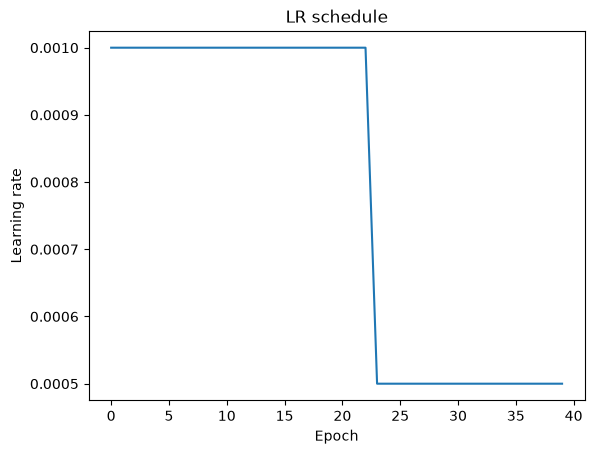

In [25]:
set_seed(9307035)
lr_model = build_baseline()  # or rebuild your regularised architecture

# TODO: choose one schedule callback, e.g.
lr_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1 #drop learning rate by 50% once we get to a plateau
)
es_cb = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

hist_lr = lr_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[lr_cb,es_cb],  # may combine with EarlyStopping
    verbose=1,
)

# TODO: plot LR vs epoch when the history key exists
lrs = hist_lr.history.get("learning_rate", [])
#print(hist_lr.history.keys())
plt.plot(lrs)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("LR schedule")
plt.show()

**LR experiment notes** (a few sentences):

- Schedule used:
   monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
- Observed effect on val curves / final accuracy:
- Would you keep this schedule for a real project?
Observed effect

One reduction at epoch 23 (0.001 → 0.0005). val_loss had been flat three epochs, then fell every epoch after, 0.2880 → 0.2802. Val accuracy jumped 0.8735 → 0.8878 immediately.
Best 0.8906 at epoch 40; ran the full 40, still improving at the cap.

Hyperparameters tested

patience 1 vs 2: 0.8904 vs 0.8906 — no difference.
factor 0.3 / 0.5 / 0.8: 0.8867 / 0.8906 / 0.8902. 
0.3 cut LR too hard; 0.8 LR needed three reductions to reach a similar rate.
min_lr never reached with any of the rates.

Would you keep it: Yes, paired with early stopping.

## 5. Save best model

Hints (Ch 7):
- Pick one of baseline / regularised / LR-tuned
- `best_model.save("something.keras")` — full architecture + weights
- `keras.models.load_model(...)` and `evaluate` on **test** once (do not retune on test)
- Commit the `.keras` file and the diagram PNG to your GitHub repo
- Filename → Moodle `a3_model_file`

In [14]:
MODEL_FILE = "imdb_sentiment_best.keras"  # Moodle a3_model_file

# TODO: choose the model object you consider best
best_model = reg_model  # or baseline or lr_model

# TODO: save
best_model.save(MODEL_FILE)

# TODO: reload and evaluate on the test set once
loaded = keras.models.load_model(MODEL_FILE)
_, test_acc = loaded.evaluate(x_test, y_test, verbose=0)

print(f"Saved model filename (Moodle a3_model_file): {MODEL_FILE}")
print(f"Test accuracy of saved model: {test_acc:.4f}")

Saved model filename (Moodle a3_model_file): imdb_sentiment_best.keras
Test accuracy of saved model: 0.8805


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_pred = (loaded.predict(x_test) > 0.5).astype(int).flatten()

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Precision: 0.8813437023971779
Recall: 0.87944
F1: 0.8803908220878549
Confusion matrix:
 [[11020  1480]
 [ 1507 10993]]


## 6. What did you learn?

Write ~200 words in the cell below (or paste the same text into Moodle if asked).
Cover: baseline vs regularised result, whether a technique hurt or helped, LR schedule takeaway, and one thing you would try next.

*Your reflection (~200 words).*

**baseline vs regularised:**
Baseline best val accuracy was 87.79% and Regularised via DropOut (with Early Stopping) was 88.82%

Baseline went to 20 epochs, validation loss was still slowly decreasing and hadn't turned upward, but the train/val accuracy gap was widening, suggesting only mild overfitting had begun.

Dropout + early stopping reached a higher accuracy but not by much, consistent with there not being much overfitting in the baseline for dropout to correct.

My saved best model was DropOut (with Early Stopping) - running against test set gave me 88% accuracy with confusion matrix looking balanced for classes.

**whether a technique hurt or helped:**

Helped: Early Stopping - helped to allow for patience to determine if the model had reached its best epoch and if it had put back the best model weights.

Hurt: None of the additions of early stopping or regularisation hurt the modelling but there is not much variation between any of the different methods with only a small percentage difference between the different models.  This is consistent with the baseline showing only mild overfitting so there wasn't much for L2 or dropout to correct.

**Testing Hyper parameters on the reg_model:**

I decided to use a seed in order to do comparison tests that did not 'bounce' around.

Drop Out Rates: I found the dropout rates between 0.1-0.5 did not alter the accuracy significantly.  
Deense Layer Widths: Comparing dense layer widths for 32,64 and 128 I found that making a layer larger than 32 did not make the accuracy improve.
Embedded Layer WIdths: Comparing embedded layer widths for 8,16,32,64,128 - I found no large difference in these - until 128 where accuracy declined.

Network Structure: GlobalAveragePooling1D averages the word vectors across the whole review, so word order is lost. Conv1D was suggested online as an alternative: a convolution layer slides over several words at a time, so local word order can be picked up before pooling. However the accuracy for this was 0.8738, below the 0.8882 from the regularised model.

**LR schedule takeaway**
The LR selected schedule helped mainly by allowing the training to run for longer once the learning rate plateaued.  Comparing to baseline this only allowed for a minor amount of improvement.  (See full write up above)

**One thing you would try next.**
Before doing any further modeles I would choose a variety of seeds to do hyper-parameter testing against before selecting a model.  
My current method of comparison was from the same seed.  I decided to use used a seed to allow for some comparison between the different model types without gettind random seed changes for each comparison.


| Model | Best val accuracy | Epochs run | Budget |
|---|---|---|---|
| Baseline | 0.8779 | 20 | 20 |
| L2 + early stopping | 0.8780 | 24 | 30 |
| Baseline + LR schedule | 0.8878 | 25 | 25 |
| Dropout + early stopping | 0.8882 | 24 | 25 |